# Análise de Desempenho: Multiplicação de Matrizes

Este notebook apresenta a análise de desempenho da multiplicação de matrizes em três cenários:
1. **Linear**: Um único núcleo.
2. **Paralelo Local**: Múltiplos núcleos na mesma máquina.
3. **Paralelo Distribuído**: Múltiplos núcleos em múltiplos backends (servidores).

Os dados são carregados do arquivo `results/stats.json`.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Configuração de estilo
plt.style.use('ggplot')

# Carregar dados
try:
    with open('results/stats.json', 'r') as f:
        data = json.load(f)
except FileNotFoundError:
    print("Arquivo 'results/stats.json' não encontrado.")
    data = []

# Processar dados para DataFrame
records = []
for entry in data:
    key = list(entry.keys())[0]
    values = entry[key]
    
    # Identificar recursos (núcleos ou servidores)
    if 'num_servers' in values:
        resources = values['num_servers'] # Distribuído usa servidores como unidade principal de 'recurso' macro, mas núcleos totais importam
        total_cores = values.get('num_cores', 0)
        mode_label = f"Distribuído ({resources} Servers, {total_cores} Cores)"
        p = total_cores # Para cálculo de eficiência, usamos o total de núcleos de processamento
    else:
        resources = values.get('num_cores', 1)
        mode_label = f"{key} ({resources} Cores)"
        p = resources

    # Benchmarks
    bench = values.get('benchmark', {})
    int_ops = bench.get('integer_benchmark', {}).get('ops_per_second', 0)
    float_ops = bench.get('float_benchmark', {}).get('ops_per_second', 0)
    
    records.append({
        'Mode': key,
        'Label': mode_label,
        'Time': values['time_seconds'],
        'Resources': p,
        'Int_Ops': int_ops,
        'Float_Ops': float_ops
    })

df = pd.DataFrame(records)

# Ordenar: Linear -> Local -> Distribuído
order_map = {'Linear': 0, 'Parallel_Local': 1, 'Parallel_Distributed': 2}
df['sort_val'] = df['Mode'].map(order_map)
df = df.sort_values('sort_val').drop('sort_val', axis=1)

display(df)

,Mode,Label,Time,Resources,Int_Ops,Float_Ops
2,Linear,Linear (1 Cores),181.925546,1,3.645059e+09,3.159974e+08
1,Parallel_Local,Parallel_Local (8 Cores),142.995713,8,2.178679e+09,2.133147e+08
0,Parallel_Distributed,"Distribuído (2 Servers, 16 Cores)",93.751898,16,3.484661e+09,3.143217e+08


## 1. Comparativo de Tempo de Execução
O gráfico abaixo compara o tempo total de execução para cada modo.

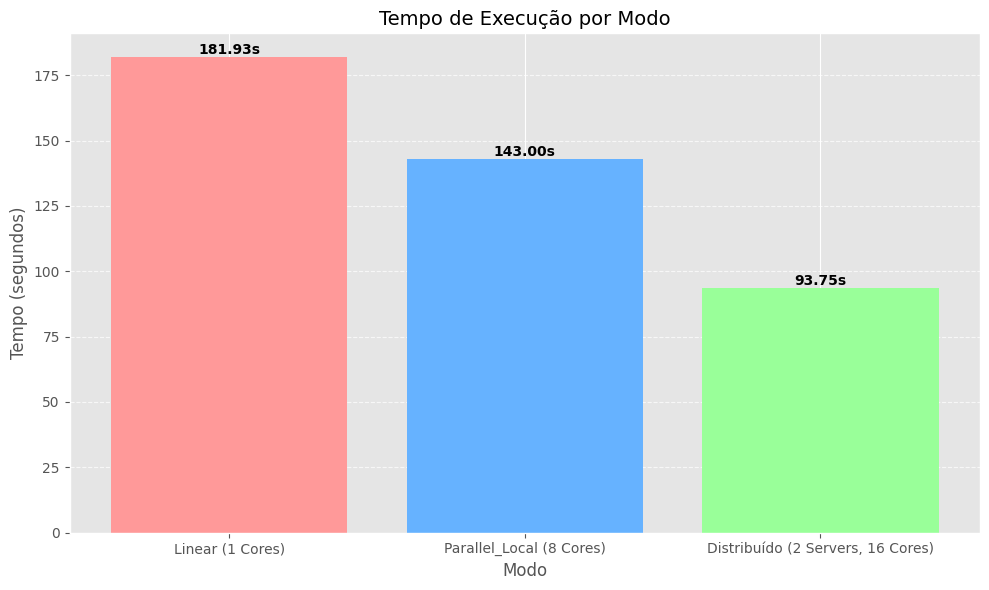

In [2]:
plt.figure(figsize=(10, 6))
bars = plt.bar(df['Label'], df['Time'], color=['#FF9999', '#66B2FF', '#99FF99'])

plt.title('Tempo de Execução por Modo', fontsize=14)
plt.ylabel('Tempo (segundos)', fontsize=12)
plt.xlabel('Modo', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}s', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 2. Benchmarks das Máquinas
Comparação da capacidade de processamento (Inteiros e Ponto Flutuante) das máquinas envolvidas.

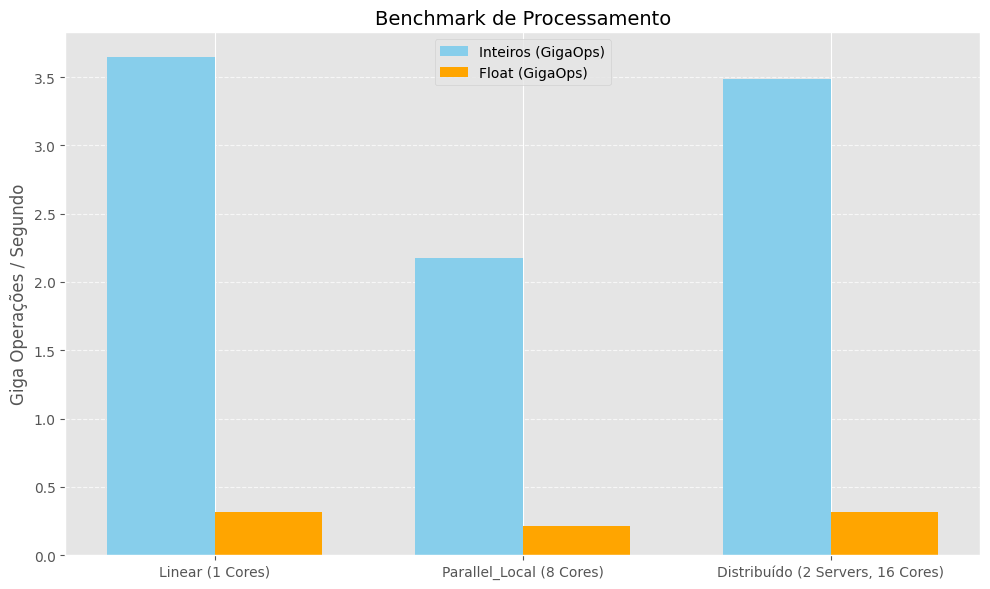

In [3]:
plt.figure(figsize=(10, 6))

x = np.arange(len(df['Label']))
width = 0.35

plt.bar(x - width/2, df['Int_Ops'] / 1e9, width, label='Inteiros (GigaOps)', color='skyblue')
plt.bar(x + width/2, df['Float_Ops'] / 1e9, width, label='Float (GigaOps)', color='orange')

plt.title('Benchmark de Processamento', fontsize=14)
plt.ylabel('Giga Operações / Segundo', fontsize=12)
plt.xticks(x, df['Label'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## 3. Speedup e Eficiência

**Fórmulas:**
- **Speedup ($S$)**: $S = \frac{T_{sequencial}}{T_{paralelo}}$
- **Eficiência ($E$)**: $E = \frac{S}{P}$, onde $P$ é o número de processadores (núcleos).

**Classificação do Speedup:**
- **Linear**: $S \approx P$
- **Sublinear**: $S < P$ (Comum devido a overhead de comunicação)
- **Superlinear**: $S > P$ (Raro, pode ocorrer devido a efeitos de cache)

In [4]:
# Obter tempo sequencial (Linear)
try:
    t_seq = df.loc[df['Mode'] == 'Linear', 'Time'].values[0]
except IndexError:
    t_seq = df['Time'].max() # Fallback se não houver Linear explícito

results = []
for index, row in df.iterrows():
    mode = row['Mode']
    t_par = row['Time']
    p = row['Resources']
    
    if mode == 'Linear':
        speedup = 1.0
        classif = 'Base'
        eff = 1.0
    else:
        speedup = t_seq / t_par
        eff = speedup / p
        
        # Classificação com margem de erro de 5%
        if speedup > p * 1.05:
            classif = 'Superlinear'
        elif speedup < p * 0.95:
            classif = 'Sublinear'
        else:
            classif = 'Linear'
            
    results.append({
        'Modo': row['Label'],
        'Tempo (s)': f"{t_par:.4f}",
        'Recursos (P)': int(p),
        'Speedup (S)': f"{speedup:.4f}",
        'Classificação': classif,
        'Eficiência (E)': f"{eff:.4f}"
    })

results_df = pd.DataFrame(results)
display(results_df)

,Modo,Tempo (s),Recursos (P),Speedup (S),Classificação,Eficiência (E)
0,Linear (1 Cores),181.9255,1,1.0000,Base,1.0000
1,Parallel_Local (8 Cores),142.9957,8,1.2722,Sublinear,0.1590
2,"Distribuído (2 Servers, 16 Cores)",93.7519,16,1.9405,Sublinear,0.1213


## 4. Análise da Metodologia Foster

A aplicação distribuída de multiplicação de matrizes foi projetada seguindo as quatro etapas da metodologia de Foster:

### 1. Decomposição (Partitioning)
O problema da multiplicação de matrizes $C = A \times B$ foi decomposto em tarefas menores baseadas em **blocos**. A matriz resultante $C$ é dividida em sub-blocos independentes. Cada tarefa é responsável por calcular um sub-bloco específico da matriz $C$, necessitando das linhas correspondentes da matriz $A$ e colunas da matriz $B$.

### 2. Comunicação (Communication)
A comunicação ocorre entre o nó mestre (cliente/orquestrador) e os nós trabalhadores (servidores). 
- **Envio**: O mestre envia os dados necessários (partes de $A$ e $B$) para cada trabalhador junto com a tarefa.
- **Recebimento**: Os trabalhadores processam o cálculo e enviam o bloco resultante de volta para o mestre.
- A comunicação é minimizada enviando apenas os blocos necessários, mas ainda representa um overhead significativo, especialmente no modo distribuído via rede.

### 3. Aglomeração (Agglomeration)
Para melhorar a eficiência e reduzir a granularidade excessiva, as tarefas de cálculo de elementos individuais foram aglomeradas em cálculos de **blocos de matrizes** (ex: 64x64 ou maior). Isso aumenta a relação computação/comunicação, garantindo que o tempo gasto calculando seja maior que o tempo transmitindo dados. Além disso, múltiplos blocos podem ser processados sequencialmente ou em paralelo dentro de um mesmo servidor (multithreading).

### 4. Mapeamento (Mapping)
O mapeamento das tarefas aos processadores é feito de forma dinâmica ou estática:
- **Paralelo Local**: O sistema operacional e a biblioteca de processamento paralelo (ex: `multiprocessing`) mapeiam as tarefas para os núcleos de CPU disponíveis na máquina local.
- **Paralelo Distribuído**: O orquestrador distribui os blocos de tarefas entre os servidores disponíveis (backends). Cada servidor, por sua vez, pode usar seus múltiplos núcleos para processar os blocos recebidos. O balanceamento de carga tenta manter todos os nós ocupados.